Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

Dataset 1 (BengaliTenseCorpus): 13500 rows, columns=['Sentence', 'Tense', 'Sentence (English Translation)']
Dataset 2 (BanglaTense): 17819 rows, columns=['Bangla Sentence', 'English Translation', 'Tense']

=== Rule-based Suffix Classifier — BengaliTenseCorpus (13,500) ===
Total sentences: 13500
Accuracy: 0.8419
              precision    recall  f1-score   support

     Present       0.70      0.97      0.81      4550
        Past       0.96      0.72      0.82      4460
      Future       0.97      0.84      0.90      4490

    accuracy                           0.84     13500
   macro avg       0.88      0.84      0.84     13500
weighted avg       0.88      0.84      0.84     13500



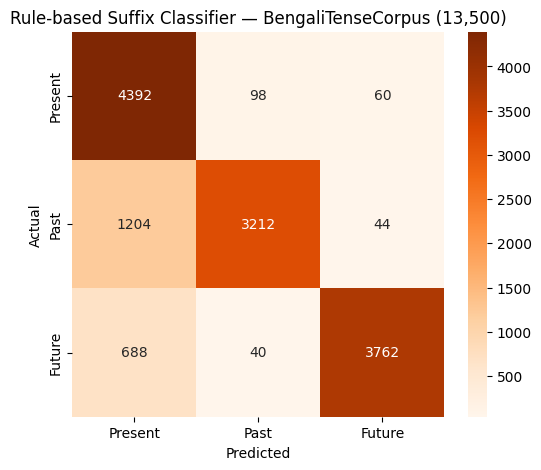


=== Rule-based Suffix Classifier — BanglaTense (17,819) ===
Total sentences: 17819
Accuracy: 0.8563
              precision    recall  f1-score   support

     Present       0.72      0.97      0.83      6101
        Past       0.96      0.75      0.84      5629
      Future       0.98      0.84      0.91      6089

    accuracy                           0.86     17819
   macro avg       0.89      0.85      0.86     17819
weighted avg       0.89      0.86      0.86     17819



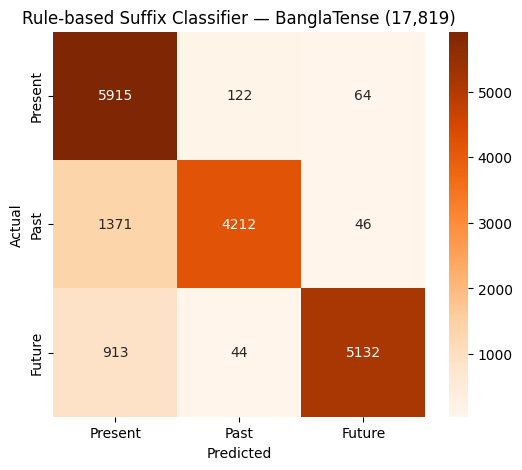


Summary — Rule-based accuracy: BengaliTenseCorpus=0.8419, BanglaTense=0.8563


In [5]:
from google.colab import drive
drive.mount('/content/drive')

import os
import re
import pandas as pd
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

folder = '/content/drive/MyDrive/Thesis_BanglaBERT'

# ------------------------------------------------------------
# STEP 1: Load both datasets
# ------------------------------------------------------------
df1 = pd.read_excel(f'{folder}/BengaliTenseCorpus.xlsx')
print(f"\nDataset 1 (BengaliTenseCorpus): {df1.shape[0]} rows, columns={df1.columns.tolist()}")

df2_path = f'{folder}/Cleaned-BanglaTense-WithEnglishTranslation.xlsx'
df2 = pd.read_excel(df2_path)
print(f"Dataset 2 (BanglaTense): {df2.shape[0]} rows, columns={df2.columns.tolist()}")

# ------------------------------------------------------------
# STEP 2: Rule-based suffix classifier (no training)
# ------------------------------------------------------------
FUTURE_SUFFIXES = ["বেন", "বো", "বে", "বি", "ব"]

PAST_SUFFIXES = [
    "য়েছিলেন", "য়েছিলাম", "য়েছিলে", "য়েছিল",
    "েছিলেন", "েছিলাম", "েছিলে", "েছিল",
    "ছিলেন", "ছিলাম", "ছিলে", "ছিলি", "ছিল",
    "ইলেন", "ইলাম", "ইল",
    "লেন", "লাম", "লে", "লি", "ল",
]

PRESENT_SUFFIXES = [
    "চ্ছেন", "চ্ছে", "চ্ছি", "চ্ছ",
    "য়েছেন", "য়েছে", "য়েছি",
    "েছেন", "েছে", "েছি", "েছ",
    "ছেন", "ছে", "ছি", "ছ",
]

_ALL_SUFFIX_RULES = (
    [(s, "Future") for s in FUTURE_SUFFIXES]
    + [(s, "Past") for s in PAST_SUFFIXES]
    + [(s, "Present") for s in PRESENT_SUFFIXES]
)
_ALL_SUFFIX_RULES.sort(key=lambda x: len(x[0]), reverse=True)

_TRAILING_PUNCT = re.compile(r"[।!?.,\"'”’…]+$")

def predict_tense_rule_based(sentence, default_label="Present"):
    cleaned = _TRAILING_PUNCT.sub("", str(sentence).strip())
    words = cleaned.split()
    if not words:
        return default_label
    last_word = words[-1]
    for suffix, label in _ALL_SUFFIX_RULES:
        if last_word.endswith(suffix):
            return label
    return default_label

# ------------------------------------------------------------
# STEP 3: Evaluate on a dataset
# ------------------------------------------------------------
def evaluate_rule_baseline(df, text_col, label_col, dataset_name):
    y_true = df[label_col]
    y_pred = df[text_col].apply(predict_tense_rule_based)

    acc = accuracy_score(y_true, y_pred)
    print(f"\n=== Rule-based Suffix Classifier — {dataset_name} ===")
    print(f"Total sentences: {len(df)}")
    print(f"Accuracy: {acc:.4f}")
    print(classification_report(y_true, y_pred, labels=["Present", "Past", "Future"]))

    cm = confusion_matrix(y_true, y_pred, labels=["Present", "Past", "Future"])
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges",
                xticklabels=["Present", "Past", "Future"],
                yticklabels=["Present", "Past", "Future"])
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Rule-based Suffix Classifier — {dataset_name}")
    plt.show()

    return acc

# ------------------------------------------------------------
# STEP 4: Run on both datasets
# ------------------------------------------------------------
acc1 = evaluate_rule_baseline(df1, "Sentence", "Tense", "BengaliTenseCorpus (13,500)")
acc2 = evaluate_rule_baseline(df2, "Bangla Sentence", "Tense", "BanglaTense (17,819)")
print(f"\nSummary — Rule-based accuracy: BengaliTenseCorpus={acc1:.4f}, BanglaTense={acc2:.4f}")



=== Rule-based Suffix Classifier (skip unmatched) — BengaliTenseCorpus (13,500) ===
Total sentences: 13500
Matched (suffix found): 8482 (62.83%)
Skipped (no suffix matched): 5018 (37.17%)
Accuracy on matched rows only: 0.9704
              precision    recall  f1-score   support

     Present       0.99      0.89      0.94      1415
        Past       0.96      0.98      0.97      3263
      Future       0.97      0.99      0.98      3804

    accuracy                           0.97      8482
   macro avg       0.97      0.95      0.96      8482
weighted avg       0.97      0.97      0.97      8482



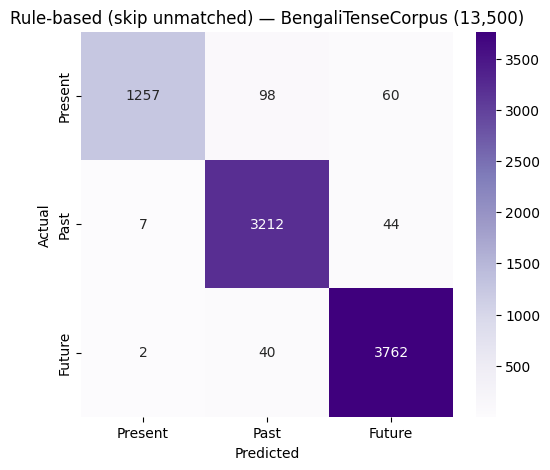


=== Rule-based Suffix Classifier (skip unmatched) — BanglaTense (17,819) ===
Total sentences: 17819
Matched (suffix found): 11672 (65.50%)
Skipped (no suffix matched): 6147 (34.50%)
Accuracy on matched rows only: 0.9755
              precision    recall  f1-score   support

     Present       1.00      0.92      0.95      2228
        Past       0.96      0.99      0.97      4265
      Future       0.98      0.99      0.98      5179

    accuracy                           0.98     11672
   macro avg       0.98      0.97      0.97     11672
weighted avg       0.98      0.98      0.98     11672



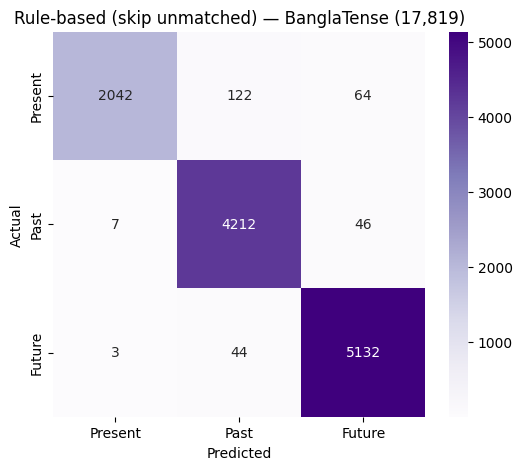


Summary:
BengaliTenseCorpus — Accuracy (matched only): 0.9704, Coverage: 62.83%
BanglaTense        — Accuracy (matched only): 0.9755, Coverage: 65.50%


In [6]:
# ------------------------------------------------------------
# STEP 5: Suffix classifier — no match then skip the row
# ------------------------------------------------------------
def predict_tense_rule_based_v2(sentence):
    cleaned = _TRAILING_PUNCT.sub("", str(sentence).strip())
    words = cleaned.split()
    if not words:
        return None
    last_word = words[-1]
    for suffix, label in _ALL_SUFFIX_RULES:
        if last_word.endswith(suffix):
            return label
    return None

# ------------------------------------------------------------
# STEP 6: Evaluate — using only the matched row
# ------------------------------------------------------------
def evaluate_rule_baseline_skip(df, text_col, label_col, dataset_name):
    y_true_all = df[label_col]
    y_pred_all = df[text_col].apply(predict_tense_rule_based_v2)

    matched_mask = y_pred_all.notna()
    total = len(df)
    matched = matched_mask.sum()
    skipped = total - matched

    y_true = y_true_all[matched_mask]
    y_pred = y_pred_all[matched_mask]

    acc = accuracy_score(y_true, y_pred)
    print(f"\n=== Rule-based Suffix Classifier (skip unmatched) — {dataset_name} ===")
    print(f"Total sentences: {total}")
    print(f"Matched (suffix found): {matched} ({matched/total*100:.2f}%)")
    print(f"Skipped (no suffix matched): {skipped} ({skipped/total*100:.2f}%)")
    print(f"Accuracy on matched rows only: {acc:.4f}")
    print(classification_report(y_true, y_pred, labels=["Present", "Past", "Future"]))

    cm = confusion_matrix(y_true, y_pred, labels=["Present", "Past", "Future"])
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Purples",
                xticklabels=["Present", "Past", "Future"],
                yticklabels=["Present", "Past", "Future"])
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Rule-based (skip unmatched) — {dataset_name}")
    plt.show()

    return acc, matched / total

# ------------------------------------------------------------
# STEP 7: final
# ------------------------------------------------------------
acc1_v2, coverage1 = evaluate_rule_baseline_skip(df1, "Sentence", "Tense", "BengaliTenseCorpus (13,500)")
acc2_v2, coverage2 = evaluate_rule_baseline_skip(df2, "Bangla Sentence", "Tense", "BanglaTense (17,819)")

print(f"\nSummary:")
print(f"BengaliTenseCorpus — Accuracy (matched only): {acc1_v2:.4f}, Coverage: {coverage1*100:.2f}%")
print(f"BanglaTense        — Accuracy (matched only): {acc2_v2:.4f}, Coverage: {coverage2*100:.2f}%")
